In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import sys
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sys.setrecursionlimit(5000)
print(f"Recursion limit set to: {sys.getrecursionlimit()}")

Recursion limit set to: 5000


In [9]:
file_path = 'promise19_dataset.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully. Here are the first 5 rows:")
print(df.head())

Dataset loaded successfully. Here are the first 5 rows:
  Project Owner                  Manager          Category         Key  \
0  Buildr   ASF  Apache Buildr Committee  build-management  BUILDR-235   
1  Buildr   ASF  Apache Buildr Committee  build-management  BUILDR-236   
2  Buildr   ASF  Apache Buildr Committee  build-management  BUILDR-239   
3  Buildr   ASF  Apache Buildr Committee  build-management  BUILDR-241   
4  Buildr   ASF  Apache Buildr Committee  build-management  BUILDR-243   

  Priority  Status        Reporter Assignee                Components  ...  \
0  Trivial  Closed     alexismidon      NaN  JRuby Site/documentation  ...   
1    Major  Closed     alexismidon      NaN                       NaN  ...   
2    Major  Closed           jmuzz      NaN             Core features  ...   
3    Major  Closed        rsutphin      NaN                       IDE  ...   
4    Minor  Closed  digitalsanctum      NaN                 Compilers  ...   

  SrcAddLines SrcDelLines Test

## EDA

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73293 entries, 0 to 73292
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Project                    73293 non-null  object 
 1   Owner                      73293 non-null  object 
 2   Manager                    73293 non-null  object 
 3   Category                   73293 non-null  object 
 4   Key                        73293 non-null  object 
 5   Priority                   73292 non-null  object 
 6   Status                     73293 non-null  object 
 7   Reporter                   73271 non-null  object 
 8   Assignee                   65176 non-null  object 
 9   Components                 46592 non-null  object 
 10  SummaryTopWords            72633 non-null  object 
 11  DescriptionTopWords        68968 non-null  object 
 12  CommentsTopWords           70286 non-null  object 
 13  CreationDate           

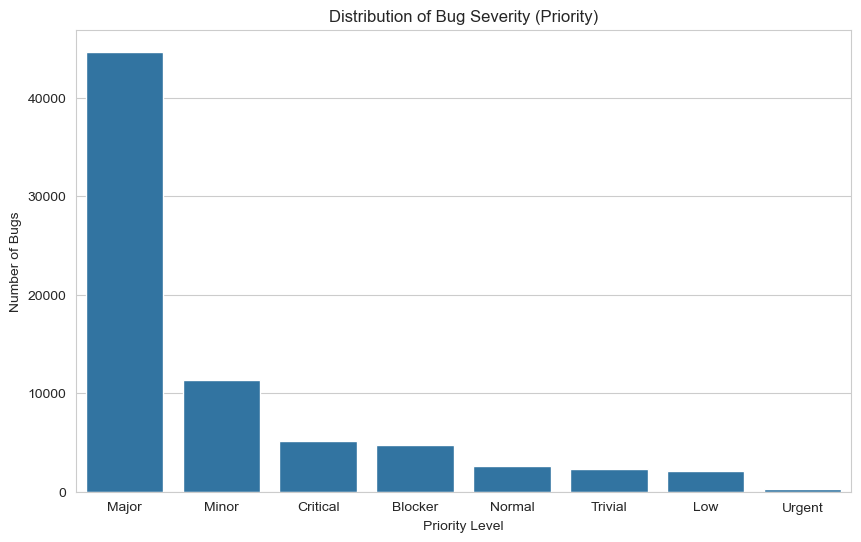

In [10]:
sns.set_style('whitegrid')

print("--- DataFrame Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
print(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())

plt.figure(figsize=(10, 6))
sns.countplot(x='Priority', data=df, order = df['Priority'].value_counts().index)
plt.title('Distribution of Bug Severity (Priority)')
plt.xlabel('Priority Level')
plt.ylabel('Number of Bugs')
plt.show()

## Preprocessing

In [11]:
df.dropna(subset=['Priority'], inplace=True)

In [12]:
df['CreationDate'] = pd.to_datetime(df['CreationDate'])
df['ResolutionDate'] = pd.to_datetime(df['ResolutionDate'])

df['BugLifetime_days'] = (df['ResolutionDate'] - df['CreationDate']).dt.days

df['BugLifetime_days'] = df['BugLifetime_days'].fillna(-1) 

In [13]:
text_features = ['SummaryTopWords', 'DescriptionTopWords', 'CommentsTopWords']

for col in text_features:
    df[col] = df[col].fillna('')

df['CombinedText'] = df[text_features].apply(lambda row: ' '.join(row), axis=1)

In [14]:
RANDOM_STATE = 42
NUM_CLASSES = 4
target_names = ['SEVERE (0)', 'HIGH (1)', 'MEDIUM (2)', 'LOW (3)']

In [15]:
df_model = df

for col in ['Components']:
    df_model[col] = df_model[col].fillna('Unknown')

def map_severity(priority):
    if priority in ['Blocker', 'Critical', 'Urgent']:
        return 0
    elif priority == 'Major':
        return 1
    elif priority in ['Normal', 'Medium']:
        return 2
    elif priority in ['Minor', 'Low', 'Trivial']:
        return 3
    return 4

df_model['target_4class'] = df_model['Priority'].apply(map_severity)
df_model = df_model[df_model['target_4class'] != 4]

In [16]:
numerical_features = [
    'NoComments', 'NoWatchers', 'NoAttachments', 'NoAttachedPatches',
    'HasMergeCommit', 'NoCommits', 'NoAuthors', 'SrcAddFiles',
    'SrcModFiles', 'SrcDelFiles', 'SrcAddLines', 'SrcDelLines',
    'TestAddLines', 'TestDelLines', 'LoC', 'BugLifetime_days'
]

categorical_features = ['Project', 'Components'] 
text_feature = 'CombinedText'
all_features = categorical_features + numerical_features + [text_feature]

X = df_model[all_features].fillna(0)
y = df_model['target_4class']

X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train shape with expanded features: {X_train.shape}")

X_train shape with expanded features: (58633, 19)


In [17]:
scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train[numerical_features])

X_test_num_scaled = scaler.transform(X_test[numerical_features])


X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns=numerical_features, index=X_train.index)
X_test_num_scaled = pd.DataFrame(X_test_num_scaled, columns=numerical_features, index=X_test.index)


X_train = X_train.drop(columns=numerical_features).join(X_train_num_scaled)
X_test = X_test.drop(columns=numerical_features).join(X_test_num_scaled)

print("Expanded numerical features scaled using StandardScaler and replaced in X_train/X_test.")

Expanded numerical features scaled using StandardScaler and replaced in X_train/X_test.


## TF-IDF and Class Weights

In [18]:
print("\n--- Feature Combination (TF-IDF) ---")
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train[text_feature])
X_test_tfidf = vectorizer.transform(X_test[text_feature])

def factorize_and_drop_text(X_df, original_X_train):
    X_df_proc = X_df.drop(columns=[text_feature]).copy()
    
    for col in categorical_features:
        mapping = {label: code for code, label in enumerate(original_X_train[col].unique())}
        X_df_proc[col] = X_df_proc[col].map(mapping).fillna(-1).astype(int)
    return X_df_proc.values

X_train_cat_num = factorize_and_drop_text(X_train, X_train)
X_test_cat_num = factorize_and_drop_text(X_test, X_train)

X_train_final = sp.hstack([X_train_cat_num, X_train_tfidf]).tocsr()
X_test_final = sp.hstack([X_test_cat_num, X_test_tfidf]).tocsr()

print(f"Final Combined Train Matrix Shape: {X_train_final.shape}")


--- Feature Combination (TF-IDF) ---
Final Combined Train Matrix Shape: (58633, 1018)


In [19]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {i: weights[i] for i in classes}
print("\n--- Class Weights Calculated ---")
print(class_weights)


--- Class Weights Calculated ---
{0: 1.7932774651333496, 1: 0.4104802576309157, 2: 6.947037914691943, 3: 1.159763430651159}


## Models and Evaluation

## LightBGM

In [20]:
print("\n" + "="*50)
print("--- Model 1: LightGBM Training (Combined Sparse Features) ---")
print("="*50)

lgbm_clf = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=NUM_CLASSES,
    n_estimators=100,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    class_weight=class_weights,
    n_jobs=-1
)

lgbm_clf.fit(X_train_final, y_train,
             eval_set=[(X_test_final, y_test)],
             eval_metric='multi_logloss',
             callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)])

y_pred_lgbm = lgbm_clf.predict(X_test_final)
print("\nLightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgbm, target_names=target_names, digits=4))


--- Model 1: LightGBM Training (Combined Sparse Features) ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.108006 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 257244
[LightGBM] [Info] Number of data points in the train set: 58633, number of used features: 1017
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294

LightGBM Classification Report:
              precision    recall  f1-score   support

  SEVERE (0)     0.3147    0.6179    0.4170      2044
    HIGH (1)     0.7712    0.5102    0.6141      8928
  MEDIUM (2)     0.5541    0.9336    0.6954       527
     LOW (3)     0.4169    0.5082    0.4581      3160

    accuracy                         0.5400     14659
   ma

## Confusion Matrix (LightBGM)

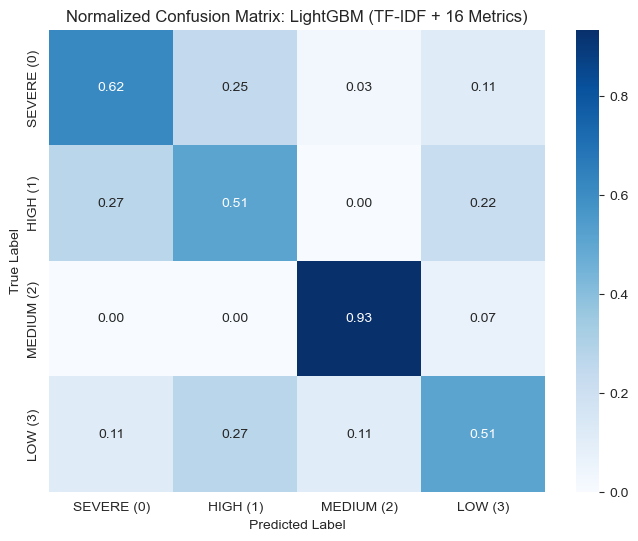

In [24]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

cm_normalized_lgbm = cm_lgbm.astype('float') / cm_lgbm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized_lgbm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix: LightGBM (TF-IDF + 16 Metrics)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('Confusion_Matrix_LightGBM.png')
plt.show()

## XGBOOST

In [25]:
try:
    from xgboost.callback import EarlyStopping
except ImportError:
    print("Warning: Could not import EarlyStopping class. Trying module import...")
    from xgboost import callback as xgb_callback
    EarlyStopping = getattr(xgb_callback, 'EarlyStopping', None)
    if EarlyStopping is None:
        raise ImportError("Could not find EarlyStopping in xgboost.callback. Check your XGBoost version.")


classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {i: weights[i] for i in classes}
sample_weights = np.array([class_weights[label] for label in y_train])

In [26]:
print("\n" + "="*50)
print("--- Model 2: XGBoost Training (Final Fix) ---")
print("="*50)

xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=NUM_CLASSES,
    n_estimators=100, 
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1
)

xgb_clf.fit(X_train_final, y_train,
            sample_weight=sample_weights,
            eval_set=[(X_test_final, y_test)],
            verbose=False)

y_pred_xgb = xgb_clf.predict(X_test_final)
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=target_names, digits=4))




--- Model 2: XGBoost Training (Final Fix) ---


C:\Users\Coral\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:199: UserWarning: [21:17:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Classification Report:
              precision    recall  f1-score   support

  SEVERE (0)     0.2992    0.6052    0.4005      2044
    HIGH (1)     0.7707    0.4773    0.5895      8928
  MEDIUM (2)     0.5353    0.9791    0.6922       527
     LOW (3)     0.3854    0.4918    0.4321      3160

    accuracy                         0.5163     14659
   macro avg     0.4976    0.6383    0.5286     14659
weighted avg     0.6134    0.5163    0.5329     14659



## Confusion Matrix (XGBoost)

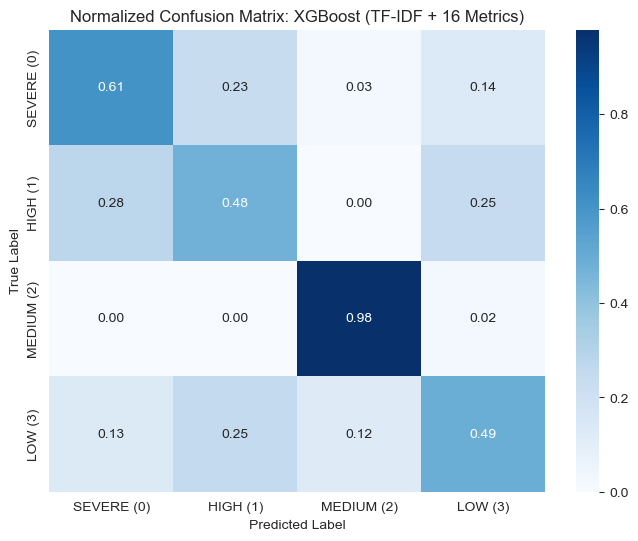

In [27]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

cm_normalized_xgb = cm_xgb.astype('float') / cm_xgb.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized_xgb, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix: XGBoost (TF-IDF + 16 Metrics)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('Confusion_Matrix_XGBoost.png')
plt.show()

## CATBOOST

In [28]:
X_train_cat = X_train.drop(columns=[text_feature])
X_test_cat = X_test.drop(columns=[text_feature])

cat_clf = CatBoostClassifier(
    loss_function='MultiClass',
    iterations=100,
    learning_rate=0.1,
    random_seed=RANDOM_STATE,
    verbose=0,
    thread_count=-1,
    class_weights=list(class_weights.values()),
    cat_features=categorical_features
)

cat_clf.fit(X_train_cat, y_train,
            eval_set=(X_test_cat, y_test),
            early_stopping_rounds=10)

y_pred_cat = cat_clf.predict(X_test_cat).flatten()

print("\nCatBoost Classification Report (No Text Features, Minimal Categoricals):")
print(classification_report(y_test, y_pred_cat, target_names=target_names, digits=4))


CatBoost Classification Report (No Text Features, Minimal Categoricals):
              precision    recall  f1-score   support

  SEVERE (0)     0.2717    0.6169    0.3773      2044
    HIGH (1)     0.7742    0.4390    0.5603      8928
  MEDIUM (2)     0.5239    0.9981    0.6871       527
     LOW (3)     0.3570    0.4465    0.3968      3160

    accuracy                         0.4855     14659
   macro avg     0.4817    0.6251    0.5054     14659
weighted avg     0.6052    0.4855    0.5041     14659



## Confusion Matrix (Catboost)

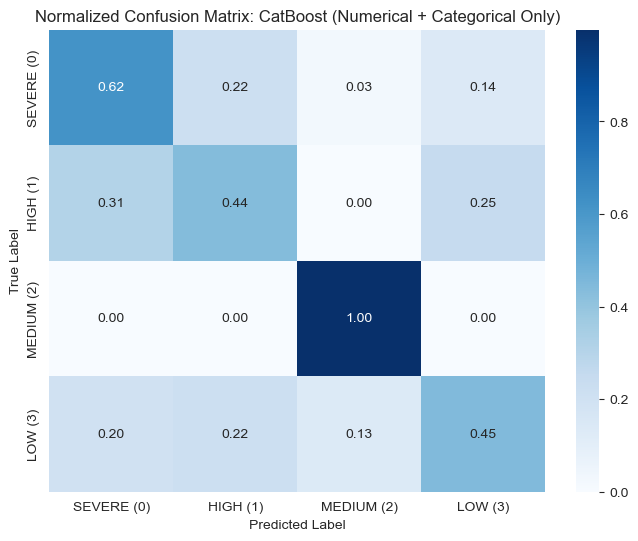

In [29]:
cm_cat = confusion_matrix(y_test, y_pred_cat)

cm_normalized_cat = cm_cat.astype('float') / cm_cat.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized_cat, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix: CatBoost (Numerical + Categorical Only)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('Confusion_Matrix_CatBoost.png')
plt.show()